In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

,id,title,release_date,overview,keywords,original_language,runtime,vote_average,vote_count,popularity,genres,director,actor1,actor2,actor3,budget,revenue,production_companies
0,11861,How to Make an American Quilt,1995-10-06,Soon-to-be-wed graduate student Finn Dodd deve...,"marriage proposal, wedding vows, married coupl...",en,116,6.384,189,1.4250,"Drama, Romance",Jocelyn Moorhouse,Winona Ryder,Anne Bancroft,Ellen Burstyn,10000000,41200020,"Universal Pictures, Amblin Entertainment"
1,492449,Killerman,2019-08-08,A New York City money launderer desperately se...,NaN,en,112,6.193,236,5.0006,"Action, Thriller",Malik Bader,Liam Hemsworth,Diane Guerrero,Emory Cohen,0,0,"Solution Entertainment Group, Deeper Water, Al..."
2,493899,"So Long, My Son",2019-03-15,Two married couples adjust to the vast social ...,NaN,zh,185,7.694,206,3.3290,Drama,Wang Xiaoshuai,Wang Jingchun,Yong Mei,Qi Xi,125000,0,"Dongchun Films, Hehe Pictures, Huerguosi Wanni..."
3,10344,The Fly II,1989-02-10,"Martin Brundle, born of the human/fly, is adop...","monster, experiment, mutation, transformation,...",en,105,5.700,696,3.8215,"Horror, Science Fiction",Chris Walas,Eric Stoltz,Daphne Zuniga,Lee Richardson,16500000,38900000,"Brooksfilms, 20th Century Fox"
4,28319,Nightmare City,1980-12-11,"In a nameless European city, a local reporter ...","vampire, apocalypse, zombie, bloodsucker, viru...",it,91,5.700,173,1.0023,"Horror, Science Fiction, Action",Umberto Lenzi,Hugo Stiglitz,Laura Trotter,Maria Rosaria Omaggio,0,0,"Dialchi Film, Lotus Films, Televicine"


In [ ]:

movies = pd.read_csv("TMBD Movie Recommendation System Dataset.csv")
movies.head()


## Genres

In [18]:
movies['genres_list'] = movies['genres'].str.split(', ')

genres_exploded = movies.explode('genres_list')

genres_exploded['genres_list'] = genres_exploded['genres_list'].str.strip()
genres_exploded = genres_exploded.dropna(subset=['genres_list'])


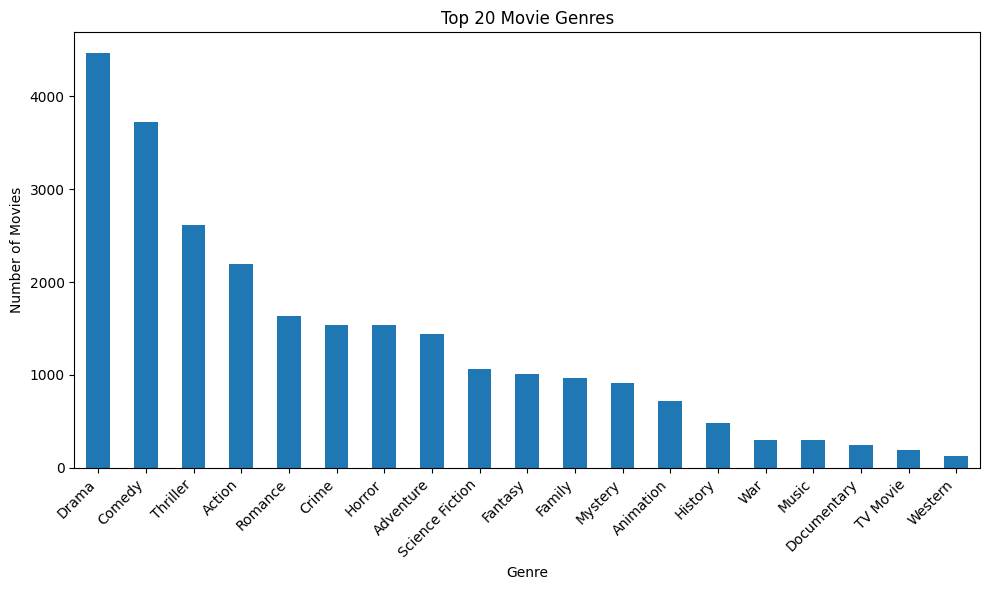

In [ ]:

genre_counts = genres_exploded['genres_list'].value_counts()

top_20_genres = genre_counts.head(20)

plt.figure(figsize=(10, 6))
top_20_genres.plot(kind='bar')
plt.title('Top 20 Movie Genres')
plt.xlabel('Genre')
plt.ylabel('Number of Movies')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()



In figure X , a movie with multiple genres contributes to multiple bars. This shows us that the most prominent movie genres are Drama and Comedy with Thriller, Action and Romance following behind them. There seems to be quite an underrepresentation of certain genres like straight-to-TV movies or westerns. This could mean that the recommendation system could be inherently biased towards specific genres since they cover more movies.


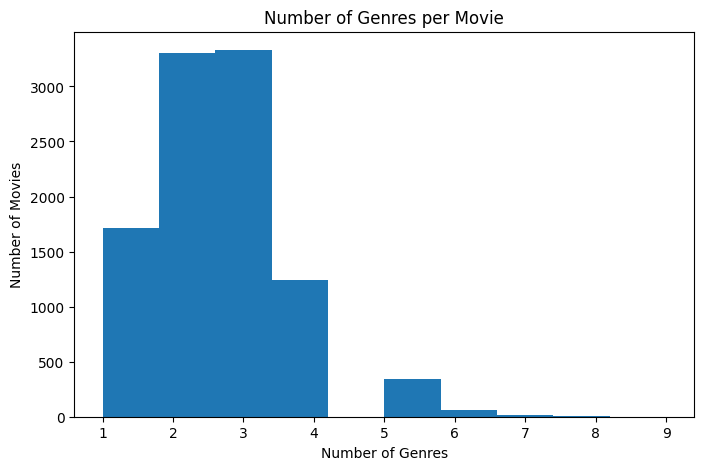

In [21]:
movies['num_genres'] = movies['genres_list'].apply(len)

plt.figure(figsize=(8, 5))
plt.hist(movies['num_genres'], bins=10)
plt.title('Number of Genres per Movie')
plt.xlabel('Number of Genres')
plt.ylabel('Number of Movies')
plt.show()


On average, movies tend to have in between 2-3 genres, with exceptions of course. Single genre movies are less common than one might think. There seems to be a small peak of movies containing between 5 to 6 genres, otherwise movies with a lot of genres are quite rare. This shows that movies are multi-label rather than single-category therefore similarity should not rely on a single genre.

## Keywords

In [22]:
movies['keywords_list'] = movies['keywords'].str.split(', ')

keywords_exploded = movies.explode('keywords_list')

keywords_exploded['keywords_list'] = keywords_exploded['keywords_list'].str.strip()
keywords_exploded = keywords_exploded.dropna(subset=['keywords_list'])


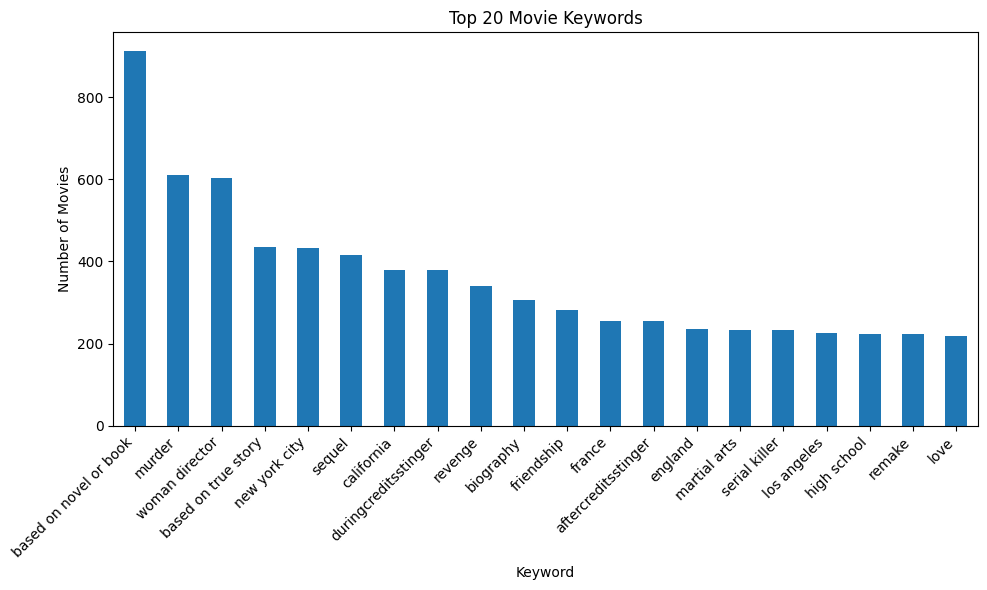

In [ ]:
import matplotlib.pyplot as plt

keyword_counts = keywords_exploded['keywords_list'].value_counts()

top_20_keywords = keyword_counts.head(20)

plt.figure(figsize=(10, 6))
top_20_keywords.plot(kind='bar')
plt.title('Top 20 Movie Keywords')
plt.xlabel('Keyword')
plt.ylabel('Number of Movies')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


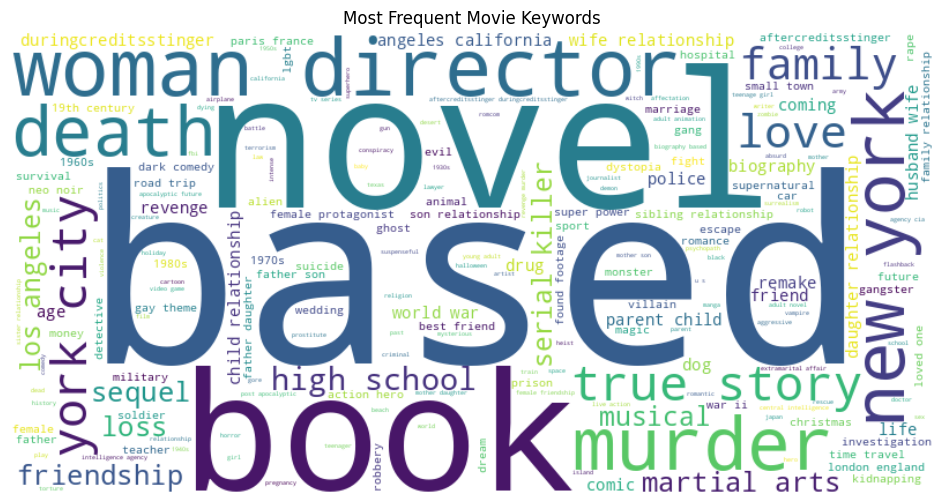

In [25]:
from wordcloud import WordCloud

all_keywords_text = ' '.join(keywords_exploded['keywords_list'])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(all_keywords_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Frequent Movie Keywords')
plt.show()


Keywords should give us the most vital information since TF-IDF heavily relies on these keywords to function. We can see there is quite some diversity in the type of the keywords we have. We have recurring narrative elements that give us a general idea of the plot (murder, friendship, serial killer…). We also get more “behind the scenes” keywords that don’t necessarily relate to the story of the movie but could still be pertinent. For example, the most common word indicates that most of the movies in our database are adaptations of novels/books. Furthermore, although “woman director” is the third most common keyword, the fact it is present in only 600 movies out of 10,000 movies proves our previous point about there being a gender bias in this data. This could potentially explain why TF-IDF would weight some keywords more strongly than others

## Runtime

In [26]:
movies_runtime = movies.dropna(subset=['runtime'])

movies_runtime = movies_runtime[
    (movies_runtime['runtime'] >= 40) & (movies_runtime['runtime'] <= 300)
]


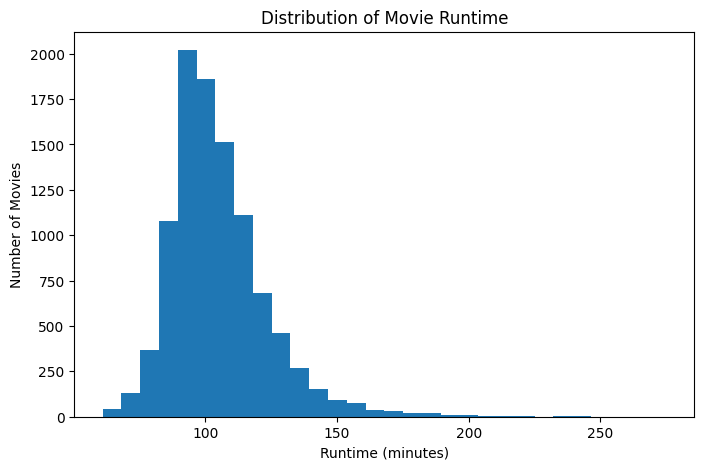

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(movies_runtime['runtime'], bins=30)
plt.title('Distribution of Movie Runtime')
plt.xlabel('Runtime (minutes)')
plt.ylabel('Number of Movies')
plt.show()

Most movies have a runtime between 90 and 120 minutes, reflecting the standard for feature-length films. However, because shorter films are more common than exceptionally long ones, the distribution is right-skewed. This non-uniform distribution informed our preprocessing strategy to filter extreme runtimes, confirming that while runtime is a useful descriptive feature, it serves as a complementary rather than a dominant factor in similarity computation.

<Figure size 1000x600 with 0 Axes>

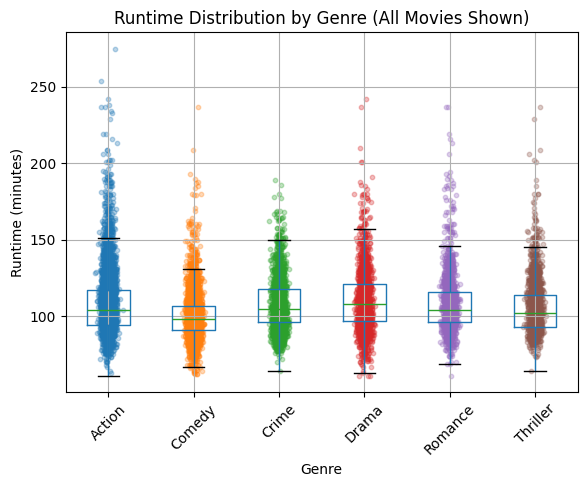

In [29]:
runtime_genres = movies_runtime.copy()
runtime_genres['genres_list'] = runtime_genres['genres'].str.split(', ')
runtime_genres = runtime_genres.explode('genres_list')

top_genres = genre_counts.head(6).index
runtime_genres = runtime_genres[runtime_genres['genres_list'].isin(top_genres)]

plt.figure(figsize=(10, 6))

runtime_genres.boxplot(
    column='runtime',
    by='genres_list',
    showfliers=False
)

for i, genre in enumerate(top_genres, start=1):
    runtimes = runtime_genres[runtime_genres['genres_list'] == genre]['runtime']
    x_jitter = np.random.normal(i, 0.04, size=len(runtimes))
    plt.scatter(
        x_jitter,
        runtimes,
        alpha=0.3,
        s=10
    )

plt.title('Runtime Distribution by Genre (All Movies Shown)')
plt.suptitle('')
plt.xlabel('Genre')
plt.ylabel('Runtime (minutes)')
plt.xticks(rotation=45)
plt.show()



When we look at how the median values vary across different genres, we notice that they are broadly similar across genres, but variability differs. It seems Drama and Action tend to have more variation in length with many of them being quite long. Comedy movies are usually shorter and closer in length to each other. This means the genre of the movie has a slight impact on its runtime. A consequence of this is that runtime can affect how similar two movies feel, even if it’s not a main factor. This shows why it’s better to use several features together (like text, genre, and runtime) instead of relying on just one.

## Language

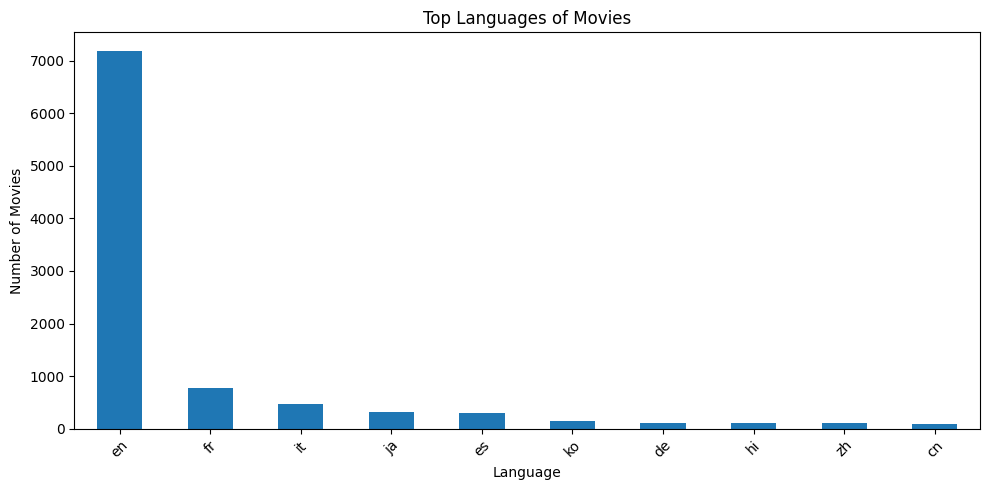

In [ ]:
import matplotlib.pyplot as plt

language_counts = movies['original_language'].value_counts()

top_languages = language_counts.head(10)

plt.figure(figsize=(10, 5))
top_languages.plot(kind='bar')
plt.title('Top Languages of Movies')
plt.xlabel('Language')
plt.ylabel('Number of Movies')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

As previously mentioned, English language movies are much more represented than any other language by a giant margin. This shows us an obvious language imbalance in the data. Non-English movies exist but represent a much smaller share, this means recommendations will most probably favor English-language movies. This explains why some users may receive fewer recommendations in other languages.

## Popularity and Rating

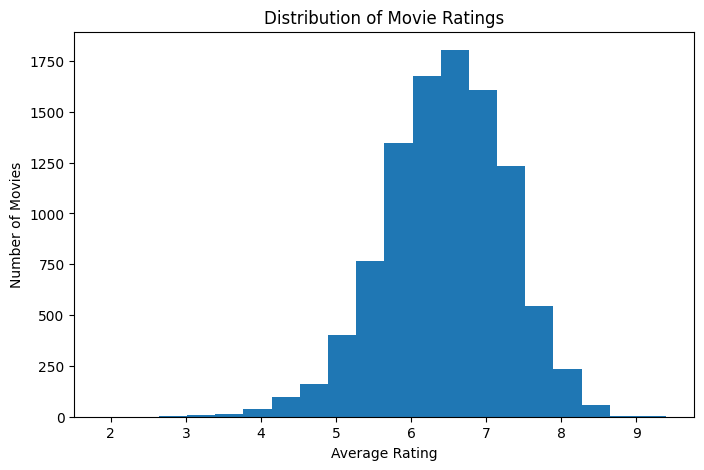

In [32]:
plt.figure(figsize=(8, 5))
plt.hist(movies['vote_average'].dropna(), bins=20)
plt.title('Distribution of Movie Ratings')
plt.xlabel('Average Rating')
plt.ylabel('Number of Movies')
plt.show()


With this histogram we can see that most of our ratings lie in the 5.5 to 7.5 range, with rarely low or high ratings. This shows that movies are mostly rated “average to good”, rather than extreme. Ratings alone do not clearly separate movies which is why using them as the main similarity feature would be ineffective. This supports our choice of content–based features like keywords.

## Budget and Revenue

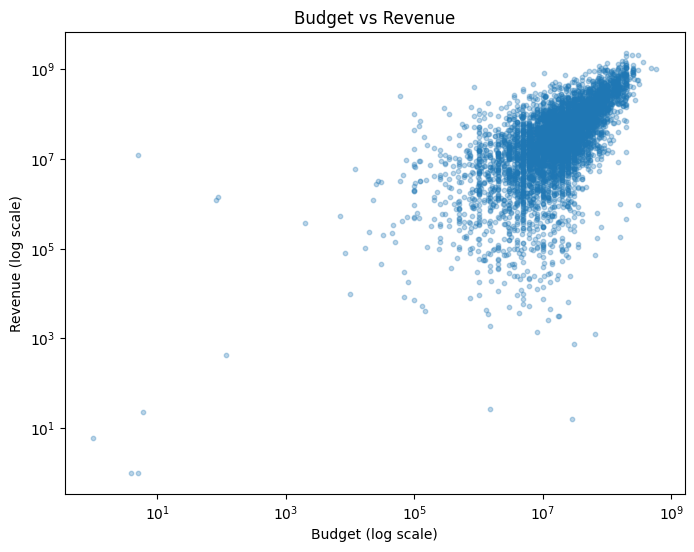

In [38]:
plt.figure(figsize=(8, 6))
plt.scatter(
    movies['budget'],
    movies['revenue'],
    alpha=0.3,
    s=10
)
plt.xscale('log')
plt.yscale('log')
plt.title('Budget vs Revenue')
plt.xlabel('Budget (log scale)')
plt.ylabel('Revenue (log scale)')
plt.show()


The scatter plot of budget versus revenue (on a logarithmic scale) reveals a positive but highly variable relationship. While higher-budget movies tend to earn more revenue on average, budget does not guarantee financial success. Several high-budget movies generate relatively low revenue, whereas some lower-budget films perform exceptionally well. This variability suggests that financial outcomes depend on many factors beyond budget and reinforces the decision to prioritize content-based features over economic metrics in the recommendation system.

## Directors

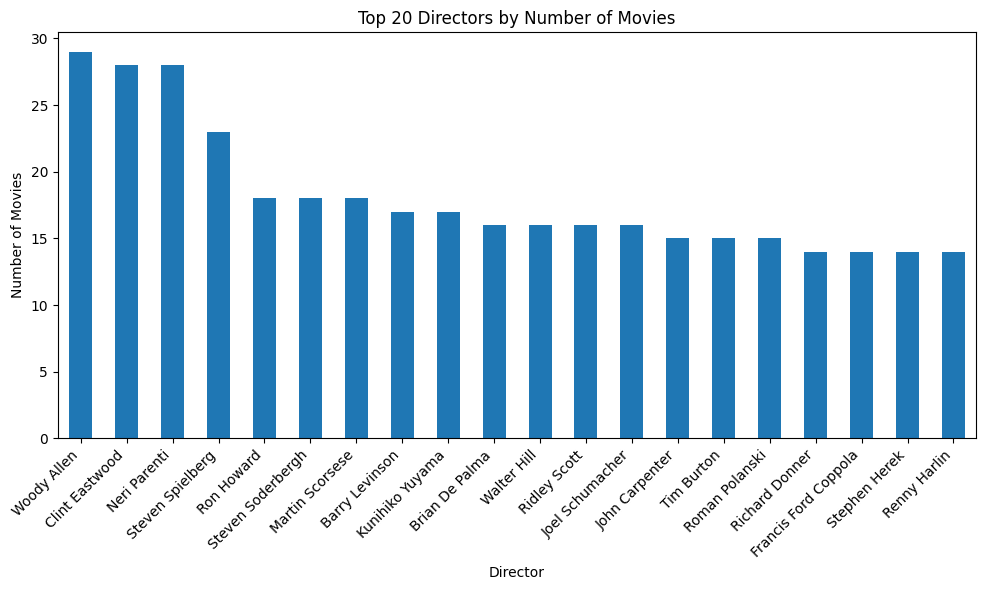

In [39]:
directors = movies.dropna(subset=['director'])

import matplotlib.pyplot as plt

director_counts = directors['director'].value_counts()

top_n = 20
top_directors = director_counts.head(top_n)

plt.figure(figsize=(10, 6))
top_directors.plot(kind='bar')
plt.title(f'Top {top_n} Directors by Number of Movies')
plt.xlabel('Director')
plt.ylabel('Number of Movies')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()



We can see from this bar chart that a small number of directors (e.g. Woody Allen, Clint Eastwood, Steven Spielberg…) appear much more frequently than others. This indicates that the dataset contains a concentration of movies from a limited set of prolific directors . Such an overrepresentation may influence similarity-based recommendations, as movies by prolific directors are more likely to be suggested simply due to their higher presence in the dataset. There is a chance this could produce bias toward well-represented filmmakers rather than lesser known ones.

## Actors

In [42]:
import pandas as pd
import matplotlib.pyplot as plt

actor_cols = ['actor1', 'actor2', 'actor3']

all_actors = movies[actor_cols].stack()

all_actors = all_actors.dropna()


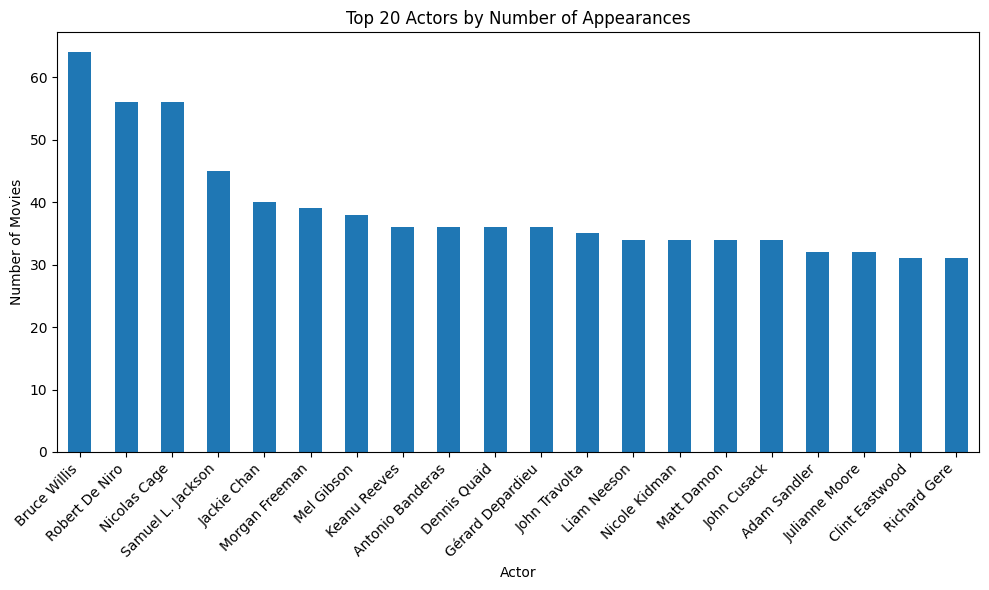

In [43]:
actor_counts = all_actors.value_counts()

top_20_actors = actor_counts.head(20)

plt.figure(figsize=(10, 6))
top_20_actors.plot(kind='bar')
plt.title('Top 20 Actors by Number of Appearances')
plt.xlabel('Actor')
plt.ylabel('Number of Movies')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


A small number of actors (e.g. Bruce Willis, Nicolas Cage, Robert De Niro) account for a disproportionately large number of movie appearances. Just like directors, this indicates a strong concentration of movies around a limited set of well-known actors. Rather than a thematic similarity between movies this could reflect industry casting patterns. This could bias similarity-based recommendations toward movies featuring popular actors. Again, just like directors, it’s better to treat actors like contextual data rather than a core similarity feature.

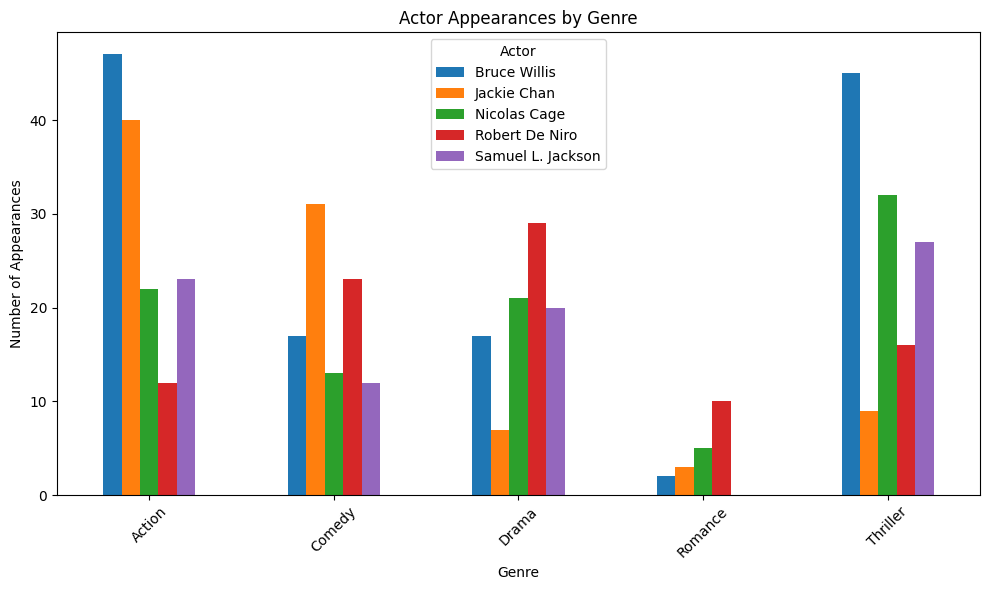

In [ ]:
movies_genres = movies.copy()
movies_genres['genres_list'] = movies_genres['genres'].str.split(', ')
movies_genres = movies_genres.explode('genres_list')

movies_actors = movies_genres.melt(
    id_vars=['genres_list'],
    value_vars=actor_cols,
    value_name='actor'
)

movies_actors = movies_actors.dropna(subset=['actor'])

top_actors = actor_counts.head(5).index
top_genres = movies_actors['genres_list'].value_counts().head(5).index

filtered = movies_actors[
    (movies_actors['actor'].isin(top_actors)) &
    (movies_actors['genres_list'].isin(top_genres))
]

actor_genre_counts = (
    filtered
    .groupby(['genres_list', 'actor'])
    .size()
    .unstack(fill_value=0)
)

actor_genre_counts.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Actor Appearances by Genre')
plt.xlabel('Genre')
plt.ylabel('Number of Appearances')
plt.xticks(rotation=45)
plt.legend(title='Actor')
plt.tight_layout()
plt.show()



## Production companies

In [ ]:
movies['production_companies_list'] = movies['production_companies'].str.split(', ')

companies_exploded = movies.explode('production_companies_list')

companies_exploded['production_companies_list'] = (
    companies_exploded['production_companies_list'].str.strip()
)
companies_exploded = companies_exploded.dropna(subset=['production_companies_list'])


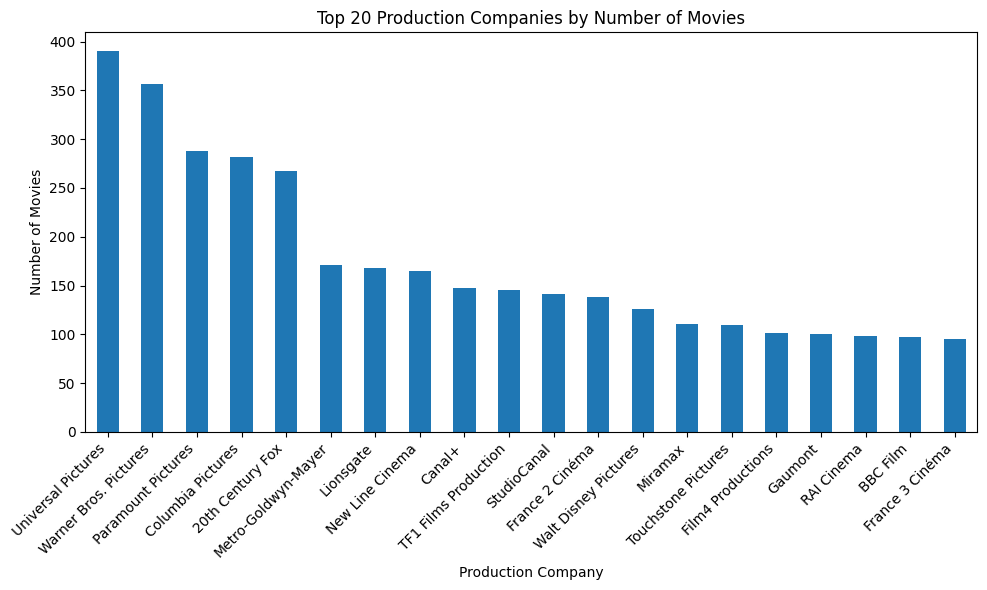

In [46]:
import matplotlib.pyplot as plt

company_counts = companies_exploded['production_companies_list'].value_counts()

top_20_companies = company_counts.head(20)

plt.figure(figsize=(10, 6))
top_20_companies.plot(kind='bar')
plt.title('Top 20 Production Companies by Number of Movies')
plt.xlabel('Production Company')
plt.ylabel('Number of Movies')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


A group of major studios, such as Universal Pictures, Warner Bros. Pictures, and Paramount Pictures, dominate the dataset, appearing far more frequently than other companies. This concentration reflects the industrial structure of the film industry, where large studios produce a substantial proportion of widely distributed films. As a result, production company information may introduce bias in similarity-based recommendations, favoring movies from well-represented studios over independent productions.

## Release date

In [ ]:
movies['release_date'] = pd.to_datetime(movies['release_date'], errors='coerce')

movies['release_year'] = movies['release_date'].dt.year

movies_year = movies.dropna(subset=['release_year'])


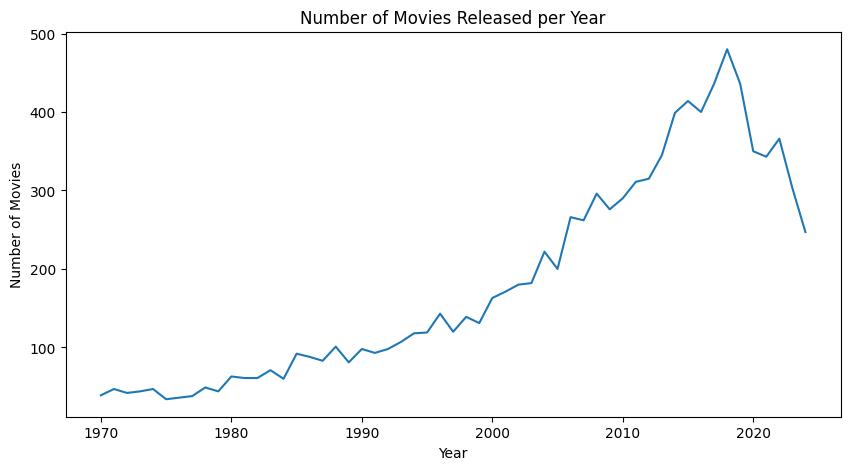

In [50]:
movies_per_year = movies_year['release_year'].value_counts().sort_index()

plt.figure(figsize=(10, 5))
plt.plot(movies_per_year.index, movies_per_year.values)
plt.title('Number of Movies Released per Year')
plt.xlabel('Year')
plt.ylabel('Number of Movies')
plt.show()


The distribution of movie release years shows a clear skew toward more recent decades, with a steady increase in the number of movies released over time. This trend is further highlighted by the yearly release curve, which indicates a gradual rise from the 1970s onward, followed by a sharp increase in the 2000s and a peak in the late 2010s. The slight decline observed in the most recent years likely reflects incomplete data rather than an actual drop in production. Overall, these figures reveal a strong temporal bias toward recent movies, suggesting that similarity-based recommendations may favor newer releases due to their higher representation in the dataset, while older films may be underrepresented despite their potential relevance to user preferences.

## Genres across users favorites

In [57]:
movie_genres = movies[['title', 'genres']].dropna()

movie_genres['genres_list'] = movie_genres['genres'].str.split(', ')


In [58]:
users['movies_list'] = users['Movie Titles'].str.split(', ')

user_movies = users.explode('movies_list')

user_movies = user_movies.rename(columns={'movies_list': 'title'})


In [59]:
user_movies_genres = user_movies.merge(
    movie_genres[['title', 'genres_list']],
    on='title',
    how='inner'
)


In [60]:
user_genres_exploded = user_movies_genres.explode('genres_list')


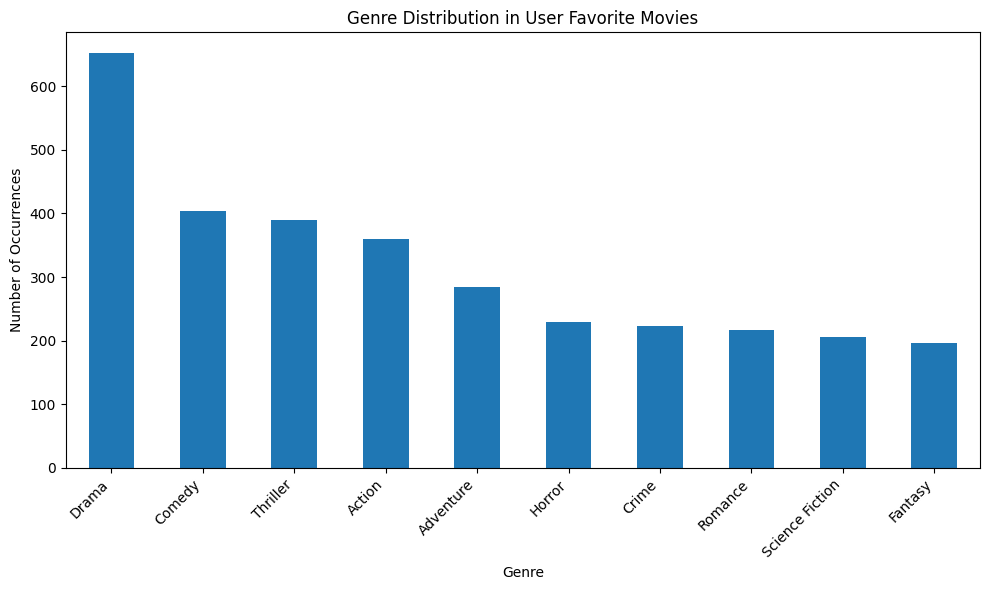

In [61]:
import matplotlib.pyplot as plt

user_genre_counts = user_genres_exploded['genres_list'].value_counts()

top_user_genres = user_genre_counts.head(10)

plt.figure(figsize=(10, 6))
top_user_genres.plot(kind='bar')
plt.title('Genre Distribution in User Favorite Movies')
plt.xlabel('Genre')
plt.ylabel('Number of Occurrences')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


This figure shows that user preferences are concentrated around a limited set of genres, with Drama and Comedy being the most frequently liked, followed by Thriller and Action. The uneven distribution indicates that users exhibit clear genre preferences rather than engaging uniformly with all available genres. This pattern highlights the importance of capturing individual tastes, as recommendations based solely on overall genre availability would fail to reflect what users actually enjoy.

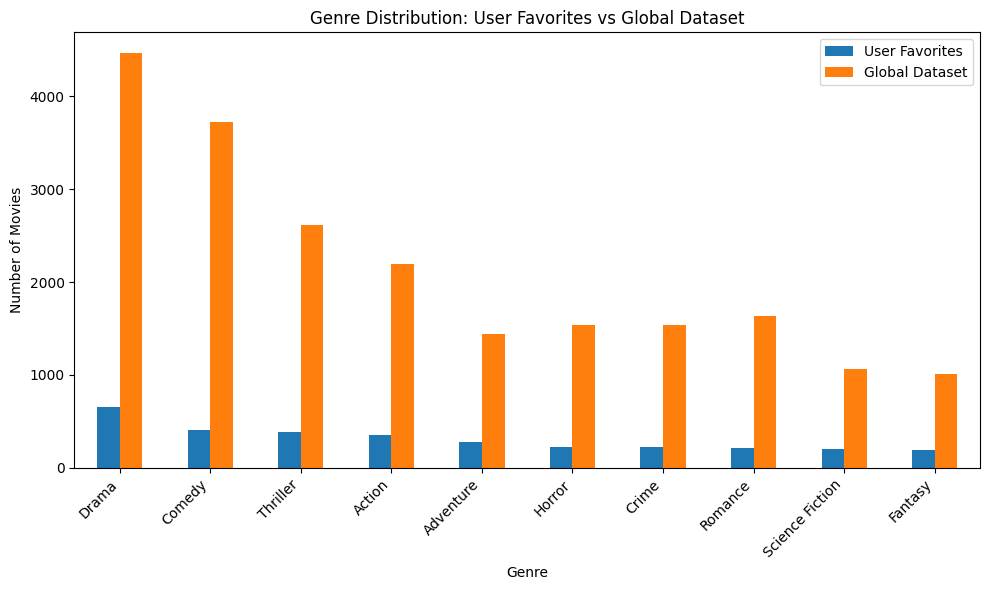

In [ ]:
movies_genres_exploded = movies.copy()
movies_genres_exploded['genres_list'] = movies_genres_exploded['genres'].str.split(', ')
movies_genres_exploded = movies_genres_exploded.explode('genres_list')

global_genre_counts = movies_genres_exploded['genres_list'].value_counts()

common_genres = (
    set(top_user_genres.index)
    & set(global_genre_counts.index)
)

comparison_df = pd.DataFrame({
    'User Favorites': user_genre_counts[list(common_genres)],
    'Global Dataset': global_genre_counts[list(common_genres)]
}).sort_values('User Favorites', ascending=False)

comparison_df.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Genre Distribution: User Favorites vs Global Dataset')
plt.xlabel('Genre')
plt.ylabel('Number of Movies')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


This comparison reveals a mismatch between the genre distribution of user favorites and that of the global movie dataset. While some dominant genres appear in both distributions, their relative importance differs, with certain genres being proportionally more popular among users than in the overall catalog. This discrepancy demonstrates that dataset composition does not directly mirror user preferences, reinforcing the need for personalized, content-based recommendation approaches.